![Image in a markdown cell](https://cursos.utnba.centrodeelearning.com/pluginfile.php/1/theme_space/customlogo/1738330016/Logo%20UTN%20Horizontal.png)



# **Diplomado de Ciencia de Datos y Análisis Avanzado**
# **TP final

---

# **Proyecto: Predicción de fraude**

## **Curso:** Diplomado en Ciencia de Datos

# **Objetivo:**
## El objetivo predecir el fraude en el set de datos www.kaggle.com/datasets/ranjitmandal/fraud-detection-dataset-csv**.


---

# 0. **Configuración Inicial e Importación de Librerías**


In [59]:
# Para manipulación de datos
import pandas as pd
import numpy as np

# Para visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Para preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Para modelado
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import compute_class_weight

#!pip install catboost

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Para evaluación
from sklearn.metrics import accuracy_score, confusion_matrix,average_precision_score, precision_score, classification_report, roc_auc_score, roc_curve, f1_score, recall_score, ConfusionMatrixDisplay
#from scipy.stats import mannwhitneyu


# Ignorar warnings para una salida más limpia (opcional)
import warnings
warnings.filterwarnings('ignore')


# **Información del Dataset**

Se utilizó el “Fraud Detection Dataset” obtenido en la plataforma Kaggle (www.kaggle.com/datasets/ranjitmandal/fraud-detection-dataset-csv).

#  **1. Carga de Datos**


In [60]:
data_df = pd.read_csv('Fraud Detection Dataset.csv')

print("Forma del dataset:", data_df.shape)

print("\nPrimeras 5 filas del dataset:")
display(data_df.head())

print("\nInformación del dataset:")
data_df.info()

#Valores faltantes
print("\nValores faltantes por columna:")
print(data_df.isnull().sum())

#Evaluación de balanceo
data_df["Fraudulent"].value_counts(normalize=True)


#Usuarios son unicos o se repiten?
total_rows = len(data_df)
unique_users = data_df["User_ID"].nunique()

print("Total filas:", total_rows)
print("Usuarios únicos:", unique_users)
print("Usuarios repetidos:", total_rows - unique_users)



Forma del dataset: (51000, 12)

Primeras 5 filas del dataset:


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0



Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  object 
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  object 
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  object 
 6   Location                          48453 non-null  object 
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  object 
 11  Fraudulent                        51000 n

# 2**. Análisis Exploratorio de Datos (EDA)**


In [61]:
data_df.columns

Index(['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type',
       'Time_of_Transaction', 'Device_Used', 'Location',
       'Previous_Fraudulent_Transactions', 'Account_Age',
       'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent'],
      dtype='object')

In [62]:
# Variables numéricas
numeric_cols = [
    "Transaction_Amount",
    "Time_of_Transaction",
    "Previous_Fraudulent_Transactions",
    "Account_Age",
    "Number_of_Transactions_Last_24H"
]
# asegurar que Fraudulent sea categórica
data_df["Fraudulent"] = data_df["Fraudulent"].astype(str)


# Variables categóricas
categorical_cols = [
    "Transaction_Type",
    "Device_Used",
    "Location",
    "Payment_Method"
]

# asegurar que Fraudulent sea categórica
data_df["Fraudulent"] = data_df["Fraudulent"].astype(str)

#Estadistica descriptiva
print("\nEstadísticas descriptivas:")
print(data_df[numeric_cols].describe())


Estadísticas descriptivas:
       Transaction_Amount  Time_of_Transaction  \
count        48480.000000         48448.000000   
mean          2996.249784            11.488400   
std           5043.932555             6.922954   
min              5.030000             0.000000   
25%           1270.552500             5.000000   
50%           2524.100000            12.000000   
75%           3787.240000            17.000000   
max          49997.800000            23.000000   

       Previous_Fraudulent_Transactions   Account_Age  \
count                      51000.000000  51000.000000   
mean                           1.995725     60.033902   
std                            1.415150     34.384131   
min                            0.000000      1.000000   
25%                            1.000000     30.000000   
50%                            2.000000     60.000000   
75%                            3.000000     90.000000   
max                            4.000000    119.000000   

       

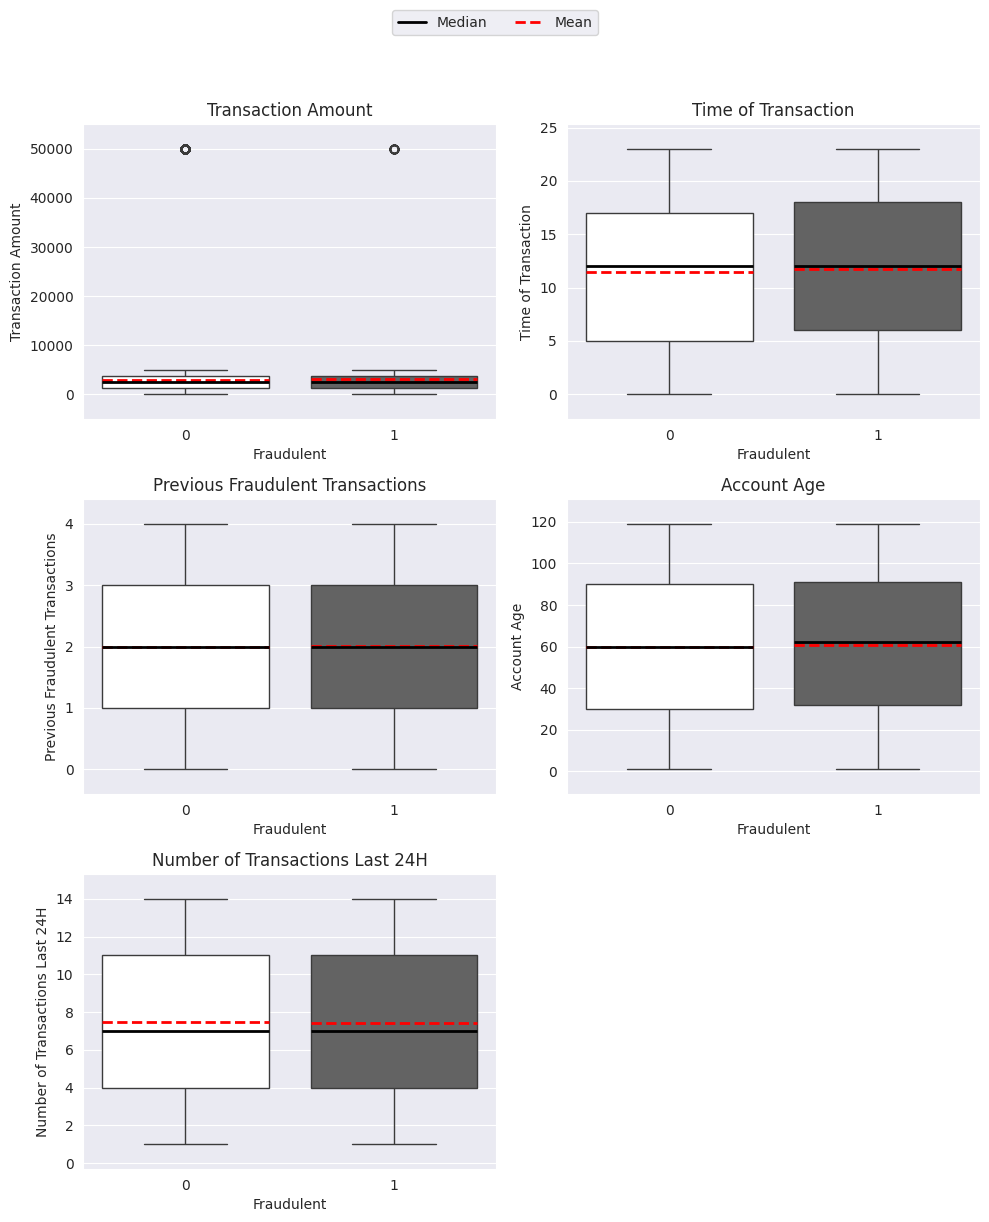

In [63]:
#Graficos box plot con las variables numericas separadas por fraude
sns.set_style("darkgrid")

n_cols = 2
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    ax = axes[i]

    sns.boxplot(
        data=data_df,
        x="Fraudulent",
        y=col,
        palette=["#FFFFFF", "#636363"],
        showfliers=True,
        medianprops={"color": "black", "linewidth": 2},
        width=0.8,
        ax=ax
    )

    means = data_df.groupby("Fraudulent")[col].mean()

    # línea de la media cubriendo toda la caja
    for j, mean in enumerate(means):
        ax.hlines(
            mean,
            j - 0.4,
            j + 0.4,
            colors="red",
            linestyles="--",
            linewidth=2
        )

    ymin = data_df[col].min()
    ymax = data_df[col].max()
    margin = (ymax - ymin) * 0.10
    ax.set_ylim(ymin - margin, ymax + margin)

    title = col.replace("_", " ")
    ax.set_title(title)

    ax.set_xlabel("Fraudulent")
    ax.set_ylabel(title)

# eliminar subplot vacío
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# leyenda fuera de la figura
legend_elements = [
    Line2D([0], [0], color="black", lw=2, label="Median"),
    Line2D([0], [0], color="red", lw=2, linestyle="--", label="Mean")
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

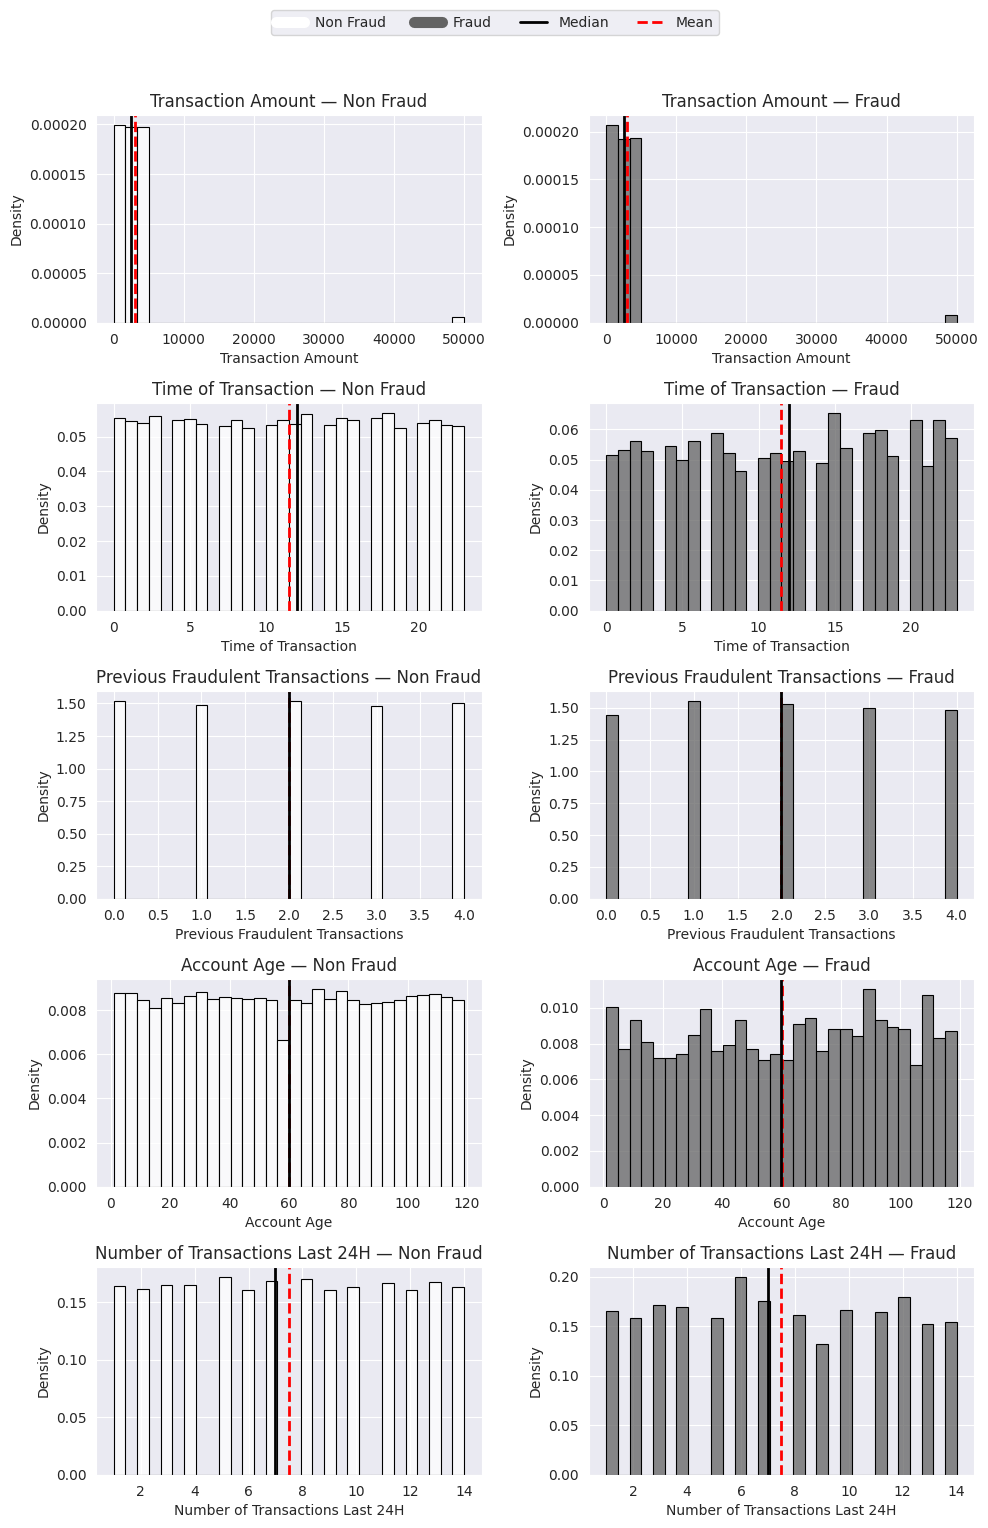

In [64]:
sns.set_style("darkgrid")

n_cols = 2
n_rows = int(np.ceil(len(numeric_cols) * 2 / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows * 3))

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    ax1 = axes[i*2]
    ax2 = axes[i*2+1]

    # Non fraud
    sns.histplot(
        data=data_df[data_df["Fraudulent"] == "0"],
        x=col,
        bins=30,
        color="#FFFFFF",
        edgecolor="black",
        linewidth=0.8,
        stat="density",
        ax=ax1
    )

    # Fraud
    sns.histplot(
        data=data_df[data_df["Fraudulent"] == "1"],
        x=col,
        bins=30,
        color="#636363",
        edgecolor="black",
        linewidth=0.8,
        stat="density",
        ax=ax2
    )

    # media y mediana
    mean = data_df[col].mean()
    median = data_df[col].median()

    for ax in [ax1, ax2]:
        ax.axvline(mean, color="red", linestyle="--", linewidth=2)
        ax.axvline(median, color="black", linewidth=2)

    title = col.replace("_", " ")

    ax1.set_title(f"{title} — Non Fraud")
    ax2.set_title(f"{title} — Fraud")

    ax1.set_xlabel(title)
    ax2.set_xlabel(title)

    ax1.set_ylabel("Density")
    ax2.set_ylabel("Density")


for j in range(len(numeric_cols)*2, len(axes)):
    fig.delaxes(axes[j])

# leyenda global
legend_elements = [
    Line2D([0], [0], color="#FFFFFF", lw=8, label="Non Fraud"),
    Line2D([0], [0], color="#636363", lw=8, label="Fraud"),
    Line2D([0], [0], color="black", lw=2, label="Median"),
    Line2D([0], [0], color="red", lw=2, linestyle="--", label="Mean")
]

fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4
)

plt.tight_layout(rect=[0,0,1,0.97])
plt.show()

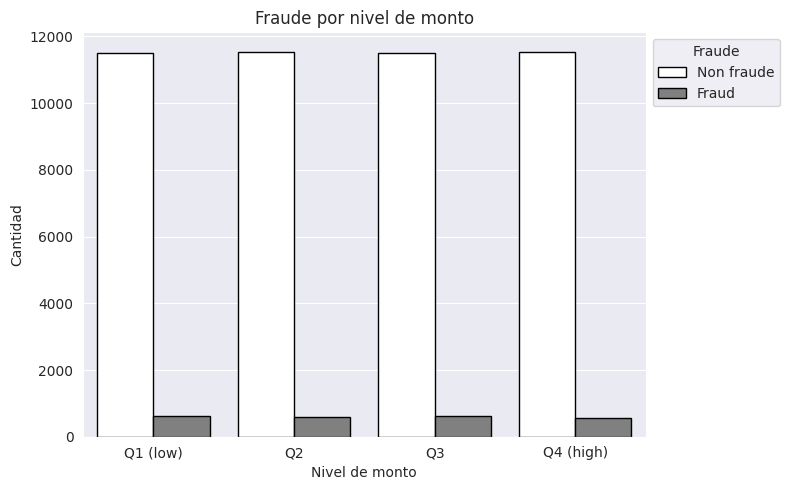

In [65]:
data_df["amount_bin"] = pd.qcut(
    data_df["Transaction_Amount"],
    q=4,
    labels=["Q1 (low)", "Q2", "Q3", "Q4 (high)"]
)

plt.figure(figsize=(8,5))

sns.countplot(
    x="amount_bin",
    hue="Fraudulent",
    data=data_df,
    palette=["white", "gray"],
    edgecolor="black"
)

plt.title("Fraude por nivel de monto")
plt.xlabel("Nivel de monto")
plt.ylabel("Cantidad")

plt.legend(
    title="Fraude",
    labels=["Non fraude", "Fraud"],
    loc="upper left",
    bbox_to_anchor=(1,1)  # mueve la leyenda afuera
)

plt.tight_layout()  # evita que se corte
plt.show()




In [32]:
for col in categorical_cols:
    print("\n", col)

    contingency_table = pd.crosstab(
        data_df[col],
        data_df["Fraudulent"])

    #print(contingency_table.to_markdown())

    display(contingency_table)


# for col in categorical_cols:
#     print("\n", col)

#     tabla = pd.crosstab(
#         data_df[col],
#         data_df["Fraudulent"],
#         normalize="index"
#     ).round(3)

#     print(tabla.to_markdown())
#     display(tabla)


 Transaction_Type


Fraudulent,0,1
Transaction_Type,,
ATM Withdrawal,9691,473
Bank Transfer,9782,494
Bill Payment,9828,512
Online Purchase,9570,524
POS Payment,9619,507



 Device_Used


Fraudulent,0,1
Device_Used,,
Desktop,15047,748
Mobile,14808,806
Tablet,14859,729
Unknown Device,1455,75



 Location


Fraudulent,0,1
Location,,
Boston,5839,310
Chicago,5737,334
Houston,5749,282
Los Angeles,5702,310
Miami,5693,298
New York,5820,290
San Francisco,5688,297
Seattle,5838,266



 Payment_Method


Fraudulent,0,1
Payment_Method,,
Credit Card,11072,574
Debit Card,11230,572
Invalid Method,1457,73
Net Banking,11092,574
UPI,11275,612


In [66]:
#Tratamiento de variables
# Imputación
data_df[categorical_cols] = data_df[categorical_cols].fillna("Unknown")
data_df[numeric_cols] = data_df[numeric_cols].fillna(data_df[numeric_cols].median())

# Asegurar target numérico
data_df["Fraudulent"] = pd.to_numeric(data_df["Fraudulent"], errors="coerce")

# One-hot encoding
df_encoded = pd.get_dummies(
    data_df,
    columns=["Transaction_Type", "Device_Used", "Location", "Payment_Method"],
    drop_first=True,
    dtype=int
)

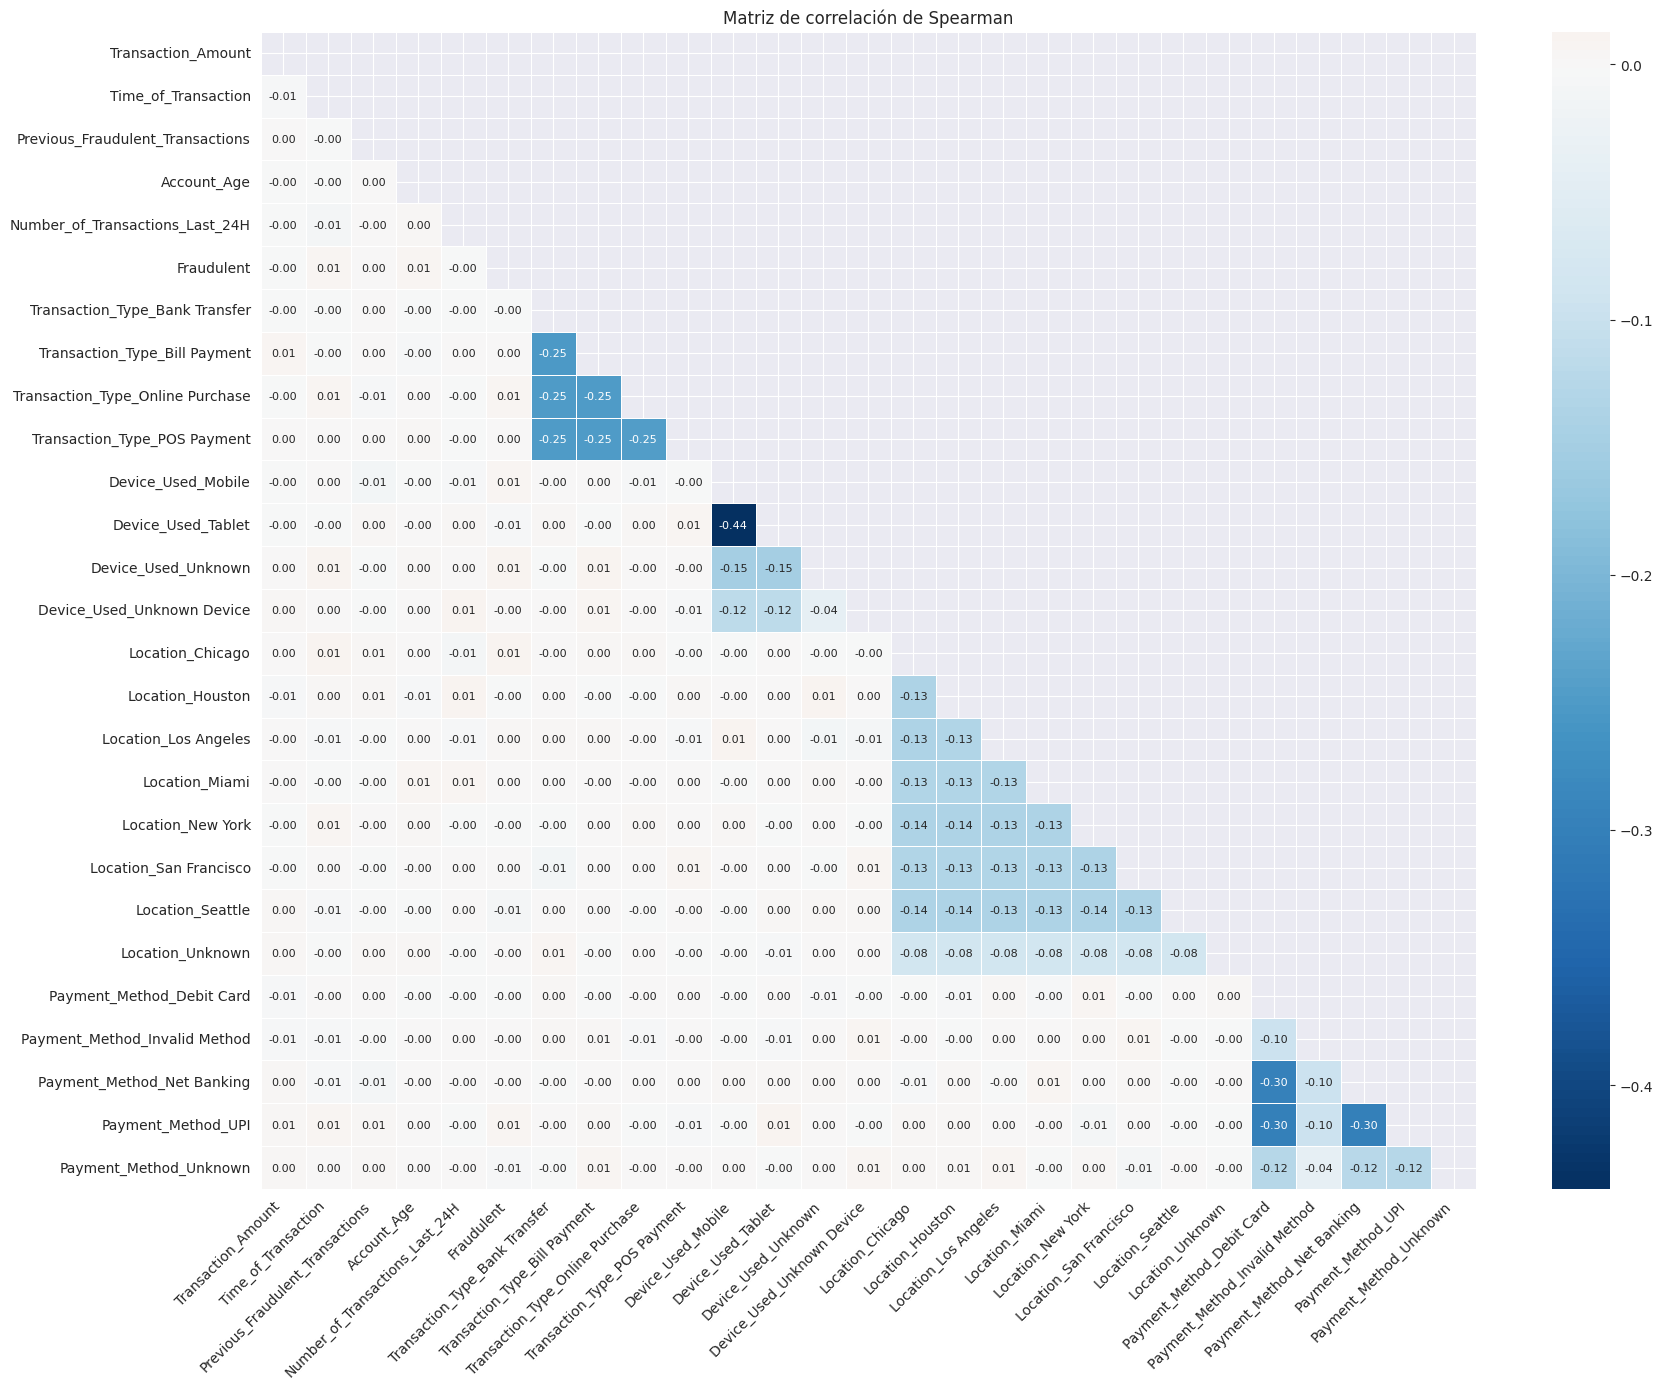

In [67]:
#Análisis Bivariado: correlacion de Spearman
# Elegir solo variables numéricas para correlación
corr_cols = df_encoded.select_dtypes(include=["number"]).columns.tolist()

# Excluir IDs
corr_cols = [c for c in corr_cols if c not in ["Transaction_ID", "User_ID"]]

# Matriz de correlación
corr_matrix = df_encoded[corr_cols].corr(method="spearman")

# Máscara triangular superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Heatmap
plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    cmap="RdBu_r",
    center=0,
    linewidths=0.5
)

plt.xticks(rotation=45, ha="right")
plt.title("Matriz de correlación de Spearman")
plt.tight_layout()
plt.show()

Fraudulent                          1.000000
Time_of_Transaction                 0.006902
Account_Age                         0.006203
Transaction_Amount                  0.005359
Previous_Fraudulent_Transactions    0.001136
Number_of_Transactions_Last_24H    -0.003877
Name: Fraudulent, dtype: float64


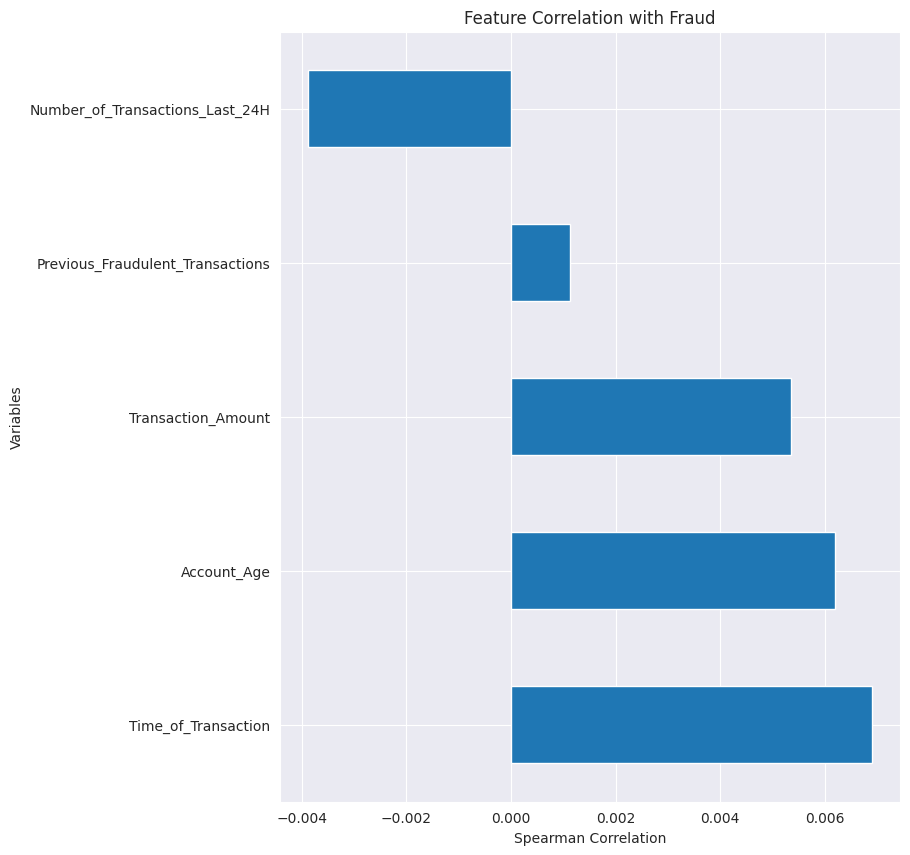

In [68]:
#Correlacion de la parte de aldi
# Seleccionar solo variables numéricas
corr_matrix = data_df.corr(numeric_only=True)

# Excluir IDs porque no tienen significado para correlación
corr_matrix = corr_matrix.drop(columns=["Transaction_ID", "User_ID"], errors="ignore")
corr_matrix = corr_matrix.drop(index=["Transaction_ID", "User_ID"], errors="ignore")

# correlación con la variable objetivo
fraud_corr = corr_matrix["Fraudulent"].sort_values(ascending=False)

print(fraud_corr)

# gráfico
plt.figure(figsize=(8,10))

fraud_corr.drop("Fraudulent").plot(kind="barh")

plt.title("Feature Correlation with Fraud")
plt.xlabel("Spearman Correlation")
plt.ylabel("Variables")

plt.show()


# **3. Preprocesamiento de Datos**

## Prepararemos los datos para que puedan ser utilizados por los modelos de Machine Learning.

In [69]:
#ESTRATEGIA 1
#Usar df_encoded para correr

In [70]:
#ESTRATEGIA 2
#Crea un nuevo df para todos estos cambios
data_df2 = data_df.copy()

##NUEVAS VARIABLES AGREGADAS...

#Agrupa las filas por User_ID y dentro de cada usuario, las ordena por Time_of_Transaction
data_df2 = data_df2.sort_values(["User_ID", "Time_of_Transaction"]).copy()


#Calcula el promedio de monto de cada usuario
data_df2["user_avg_amount"] = data_df2.groupby("User_ID")["Transaction_Amount"].transform("mean")
#Desviación respecto a su comportamiento habitual de cada usuario
data_df2["amount_ratio_vs_user_avg"] = (
    data_df2["Transaction_Amount"] / (data_df2["user_avg_amount"] + 1)
)


#Dispositivo anterior del usuario
data_df2["prev_device"] = data_df2.groupby("User_ID")["Device_Used"].shift(1)
#Indicador de cambio de dispositivo
data_df2["device_changed"] = (
   data_df2["Device_Used"] != data_df2["prev_device"]
).astype(int)


#Metodo de pago anterior
data_df2["prev_payment_method"] = data_df2.groupby("User_ID")["Payment_Method"].shift(1)
#Indicador de método de pago
data_df2["payment_method_changed"] = (
    data_df2["Payment_Method"] != data_df2["prev_payment_method"]
).astype(int)


#Ubicación anterior
data_df2["prev_location"] = data_df2.groupby("User_ID")["Location"].shift(1)
#Indicador de cambio de ubicación
data_df2["location_changed"] = (
   data_df2["Location"] != data_df2["prev_location"]
).astype(int)

#Cantidad de transacciones previas del usuario
data_df2["user_transaction_number"] = data_df2.groupby("User_ID").cumcount()

#limpia los nuevos NA generados por shift
data_df2["prev_device"] = data_df2["prev_device"].fillna("No Previous Device")
data_df2["prev_payment_method"] = data_df2["prev_payment_method"].fillna("No Previous Payment")
data_df2["prev_location"] = data_df2["prev_location"].fillna("No Previous Location")

#one-hot encoding
df_encoded2 = pd.get_dummies(
    data_df2,
    columns=[
        "Transaction_Type",
        "Device_Used",
        "Location",
        "Payment_Method",
        "prev_device",
        "prev_payment_method",
        "prev_location"
    ],
    drop_first=True,
    dtype=int
)

display(data_df2,10)
#display(df_encoded2,10)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,...,amount_bin,user_avg_amount,amount_ratio_vs_user_avg,prev_device,device_changed,prev_payment_method,payment_method_changed,prev_location,location_changed,user_transaction_number
4523,T4524,1000,1543.51,Bill Payment,3.0,Unknown,Miami,3,2,1,...,Q2,2232.880000,0.690955,No Previous Device,1,No Previous Payment,1,No Previous Location,1,0
38443,T38444,1000,3140.55,Online Purchase,4.0,Desktop,Los Angeles,1,104,11,...,Q3,2232.880000,1.405872,Unknown,1,Net Banking,1,Miami,1,1
15308,T15309,1000,4394.37,Bill Payment,10.0,Tablet,Chicago,0,61,8,...,Q4 (high),2232.880000,1.967147,Desktop,1,Invalid Method,1,Los Angeles,1,2
22242,T22243,1000,982.92,Bill Payment,10.0,Mobile,Houston,2,98,8,...,Q1 (low),2232.880000,0.440006,Tablet,1,Net Banking,0,Chicago,1,3
29112,T29113,1000,1197.00,Bill Payment,10.0,Mobile,Seattle,2,40,2,...,Q1 (low),2232.880000,0.535839,Mobile,0,Net Banking,1,Houston,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23536,T23537,4999,3927.54,POS Payment,12.0,Mobile,Unknown,1,103,4,...,Q4 (high),2844.265385,1.380377,Mobile,0,Net Banking,1,Seattle,1,8
33314,T33315,4999,1347.04,Bill Payment,19.0,Tablet,Boston,2,1,5,...,Q2,2844.265385,0.473432,Mobile,1,UPI,1,Unknown,1,9
43020,T43021,4999,91.28,Bank Transfer,20.0,Mobile,Miami,0,35,13,...,Q1 (low),2844.265385,0.032081,Tablet,1,Debit Card,0,Boston,1,10
7543,T7544,4999,2770.47,POS Payment,22.0,Mobile,San Francisco,3,87,1,...,Q3,2844.265385,0.973712,Mobile,0,Debit Card,0,Miami,1,11


10

In [71]:
#Preparacion de los datos
def prepare_strategy_data(df_encoded, target_col="Fraudulent"):

    df = df_encoded.copy()

    df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

    # target
    y = df[target_col]

    # groups para evitar que un mismo usuario esté en train y test
    groups = df["User_ID"]

    # features: saco target y Transaction_ID, pero dejo User_ID momentáneamente
    X = df.drop(columns=[target_col, "Transaction_ID", "amount_bin"], errors="ignore")

    # split por usuario
    gss = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=42
    )

    train_idx, test_idx = next(gss.split(X, y, groups))

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

    # ahora sí saco User_ID para modelar
    X_train = X_train.drop(columns=["User_ID"], errors="ignore")
    X_test = X_test.drop(columns=["User_ID"], errors="ignore")

    # escalado
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # SMOTE solo en train
    smote = SMOTE(random_state=42)
    X_train_scaled, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

    return {
        "X_train_scaled": X_train_scaled,
        "X_test_scaled": X_test_scaled,
        "y_train": y_train_balanced,
        "y_test": y_test
    }

# **4. Modelado y Evaluación**

In [72]:
#Modelos elegidos
def build_models():

    models = {

        "LogReg": {
            "model": Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    max_iter=500,
                    random_state=42
                ))
            ]),
            "use_scaled": False
        },

        "KNN": {
            "model": Pipeline([
                ("scaler", StandardScaler()),
                ("model", KNeighborsClassifier(n_neighbors=15))
            ]),
            "use_scaled": False
        },

        "DecisionTree": {
            "model": DecisionTreeClassifier(
                max_depth=6,
                random_state=42
            ),
            "use_scaled": False
        },

        "RandomForest": {
            "model": RandomForestClassifier(
                n_estimators=500,
                random_state=42
            ),
            "use_scaled": False
        },

        "GradientBoosting": {
            "model": GradientBoostingClassifier(random_state=42),
            "use_scaled": False
        },

        "XGBoost": {
            "model": XGBClassifier(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42
            ),
            "use_scaled": False
        },

        "LightGBM": {
            "model": LGBMClassifier(
                n_estimators=500,
                learning_rate=0.05,
                random_state=42,
                verbose=-1
            ),
            "use_scaled": False
        },

        "CatBoost": {
            "model": CatBoostClassifier(
                iterations=500,
                learning_rate=0.05,
                depth=6,
                verbose=0,
                random_state=42
            ),
            "use_scaled": False
        }
    }

    return models


# Preparacion de los datos
def prepare_strategy_data(df_encoded, target_col="Fraudulent"):

    df = df_encoded.copy()

    df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

    X = df.drop(columns=[target_col], errors="ignore")
    y = df[target_col]

    # Drop 'amount_bin' column before scaling
    X = X.drop(columns=["Transaction_ID", "User_ID", "amount_bin"], errors="ignore")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    smote = SMOTE(random_state=42)

    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    X_train_scaled_balanced, y_train_scaled_balanced = smote.fit_resample(X_train_scaled, y_train)

    return {
        "X_train": X_train_balanced,
        "X_test": X_test,
        "X_train_scaled": X_train_scaled_balanced,
        "X_test_scaled": X_test_scaled,
        "y_train": y_train_balanced,
        "y_train_scaled": y_train_scaled_balanced,
        "y_test": y_test
    }


# Evaluacion de los modelos
def evaluate_models(models, data, strategy_name):

    results = []
    roc_data = []

    for name, spec in models.items():

        model = spec["model"]
        use_scaled = spec["use_scaled"]

        Xtr = data["X_train_scaled"] if use_scaled else data["X_train"]
        Xte = data["X_test_scaled"] if use_scaled else data["X_test"]
        ytr = data["y_train_scaled"] if use_scaled else data["y_train"]

        print(f"[{strategy_name}] Training {name}")

        model.fit(Xtr, ytr)
        y_pred = model.predict(Xte)

        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(Xte)[:, 1]
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(Xte)
        else:
            y_score = y_pred

        results.append([
            strategy_name,
            name,
            roc_auc_score(data["y_test"], y_score),
            average_precision_score(data["y_test"], y_score),
            f1_score(data["y_test"], y_pred, zero_division=0),
            accuracy_score(data["y_test"], y_pred),
            recall_score(data["y_test"], y_pred, zero_division=0),
            precision_score(data["y_test"], y_pred, zero_division=0)
        ])

        fpr, tpr, _ = roc_curve(data["y_test"], y_score)
        roc_data.append((strategy_name, name, fpr, tpr))

    return pd.DataFrame(results, columns=[
        "Strategy", "Model", "ROC_AUC", "PR_AUC",
        "F1", "Accuracy", "Recall", "Precision"
    ]), roc_data


#Corrida estrategia 1
data_s1 = prepare_strategy_data(df_encoded)
models_s1 = build_models()
results_s1, roc_s1 = evaluate_models(models_s1, data_s1, "Estrategia_1")

# Corrida estrategia 2
data_s2 = prepare_strategy_data(df_encoded2)
models_s2 = build_models()
results_s2, roc_s2 = evaluate_models(models_s2, data_s2, "Estrategia_2")


[Estrategia_1] Training LogReg
[Estrategia_1] Training KNN
[Estrategia_1] Training DecisionTree
[Estrategia_1] Training RandomForest
[Estrategia_1] Training GradientBoosting
[Estrategia_1] Training XGBoost
[Estrategia_1] Training LightGBM
[Estrategia_1] Training CatBoost
[Estrategia_2] Training LogReg
[Estrategia_2] Training KNN
[Estrategia_2] Training DecisionTree
[Estrategia_2] Training RandomForest
[Estrategia_2] Training GradientBoosting
[Estrategia_2] Training XGBoost
[Estrategia_2] Training LightGBM
[Estrategia_2] Training CatBoost


In [73]:
#Definición de la DNN
def build_dnn(input_dim):

    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(64, activation="relu"),
        Dropout(0.3),

        Dense(32, activation="relu"),
        Dropout(0.2),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")
        ]
    )

    return model


#Entrenamiento y evaluación de la DNN
def evaluate_dnn(data, strategy_name, threshold=0.5):

    X_train_scaled = data["X_train_scaled"]
    X_test_scaled = data["X_test_scaled"]
    y_train = data["y_train_scaled"] if "y_train_scaled" in data else data["y_train"]
    y_test = data["y_test"]

    dnn_model = build_dnn(X_train_scaled.shape[1])

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = dnn_model.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=30,
        batch_size=256,
        callbacks=[early_stop],
        verbose=1
    )

    y_score_dnn = dnn_model.predict(X_test_scaled).ravel()
    y_pred_dnn = (y_score_dnn >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred_dnn)
    f1 = f1_score(y_test, y_pred_dnn, zero_division=0)
    recall = recall_score(y_test, y_pred_dnn, zero_division=0)
    precision = precision_score(y_test, y_pred_dnn, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_score_dnn)
    pr_auc = average_precision_score(y_test, y_score_dnn)

    print(f"\nDNN Results - {strategy_name}")
    print("Accuracy:", accuracy)
    print("F1:", f1)
    print("Recall:", recall)
    print("Precision:", precision)
    print("ROC_AUC:", roc_auc)
    print("PR_AUC:", pr_auc)

    dnn_results = pd.DataFrame([[
        strategy_name,
        "DNN",
        roc_auc,
        pr_auc,
        f1,
        accuracy,
        recall,
        precision
    ]], columns=[
        "Strategy", "Model", "ROC_AUC", "PR_AUC",
        "F1", "Accuracy", "Recall", "Precision"
    ])

    fpr, tpr, _ = roc_curve(y_test, y_score_dnn)
    dnn_roc = (strategy_name, "DNN", fpr, tpr)

    return dnn_model, history, dnn_results, dnn_roc


# Corrida DNN estrategia 1
dnn_model_s1, history_s1, results_dnn_s1, roc_dnn_s1 = evaluate_dnn(
    data_s1,
    "Estrategia_1"
)

# Corrida DNN estrategia 2
dnn_model_s2, history_s2, results_dnn_s2, roc_dnn_s2 = evaluate_dnn(
    data_s2,
    "Estrategia_2"
)

Epoch 1/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - auc: 0.5304 - loss: 0.6813 - precision: 0.3998 - recall: 0.1386 - val_auc: 0.0000e+00 - val_loss: 0.9770 - val_precision: 1.0000 - val_recall: 3.8667e-04
Epoch 2/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.5767 - loss: 0.6528 - precision: 0.4651 - recall: 0.0520 - val_auc: 0.0000e+00 - val_loss: 0.9668 - val_precision: 1.0000 - val_recall: 0.0015
Epoch 3/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.6046 - loss: 0.6452 - precision: 0.5328 - recall: 0.0636 - val_auc: 0.0000e+00 - val_loss: 0.9130 - val_precision: 1.0000 - val_recall: 0.0271
Epoch 4/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.6284 - loss: 0.6370 - precision: 0.5658 - recall: 0.0968 - val_auc: 0.0000e+00 - val_loss: 0.9306 - val_precision: 1.0000 - val_recall: 0.0622
Epoch 5/30
243/243 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - auc: 0.6483 - loss: 0.6293 - precision: 0.5733 - recall: 0.1416 - val_auc: 0.0000e+00 - val_loss: 0.9040 - val_precision: 1.00

,Strategy,Model,ROC_AUC,PR_AUC,F1,Accuracy,Recall,Precision
2,Estrategia_1,DecisionTree,0.518861,0.052024,0.088448,0.765588,0.231076,0.054691
16,Estrategia_1,DNN,0.502163,0.049711,0.065789,0.846863,0.109562,0.047009
0,Estrategia_1,LogReg,0.511953,0.051107,0.069414,0.873824,0.095618,0.054484
1,Estrategia_1,KNN,0.502677,0.049625,0.057182,0.864216,0.083665,0.043433
4,Estrategia_1,GradientBoosting,0.515900,0.051705,0.061934,0.878235,0.081673,0.049878
3,Estrategia_1,RandomForest,0.531586,0.058033,0.074369,0.931667,0.055777,0.111554
5,Estrategia_1,XGBoost,0.512003,0.050797,0.023529,0.926765,0.017928,0.034221
7,Estrategia_1,CatBoost,0.519043,0.051560,0.022039,0.930392,0.015936,0.035714
6,Estrategia_1,LightGBM,0.510493,0.050444,0.022654,0.940784,0.013944,0.060345
10,Estrategia_2,DecisionTree,0.510598,0.050332,0.076923,0.774118,0.191235,0.048144


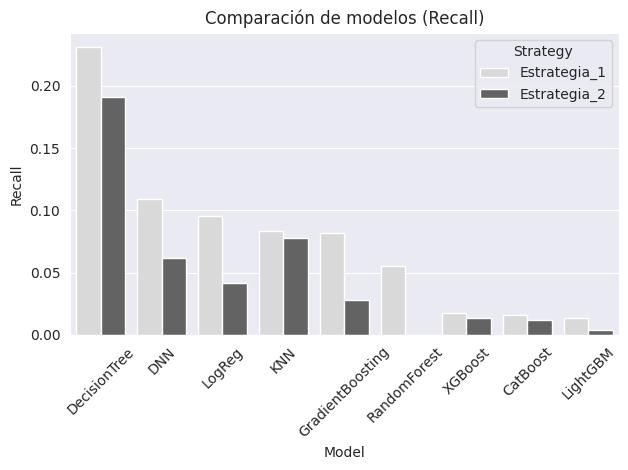

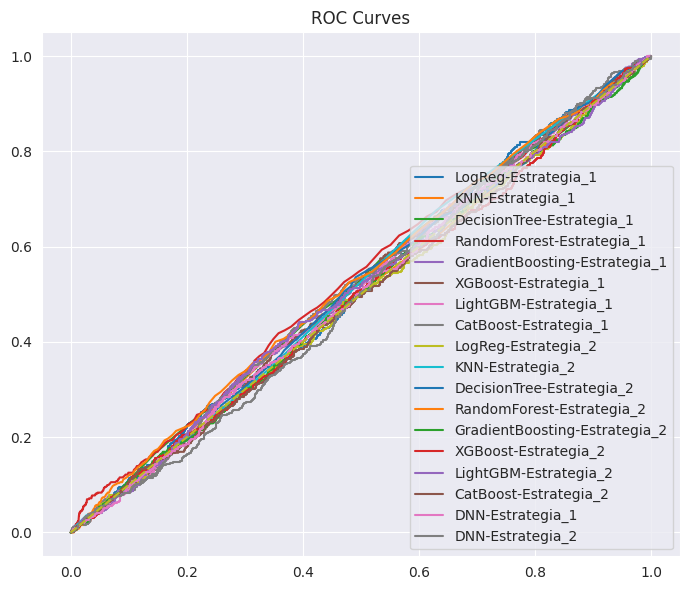

In [75]:
# Resultados de todos los modelos + DNN
results_all = pd.concat(
    [results_s1, results_s2, results_dnn_s1, results_dnn_s2],
    ignore_index=True
)

results_all = results_all.sort_values(
    ["Strategy", "Recall"],
    ascending=[True, False]
)

display(results_all)

#Grafico de comparacion entre los modelos por PR_AUC
sns.barplot(
    data=results_all,
    x="Model",
    y="Recall",
    hue="Strategy",
    palette=["#D9D9D9", "#636363"]
)
plt.xticks(rotation=45)
plt.title("Comparación de modelos (Recall)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,6))

for strategy, name, fpr, tpr in roc_s1 + roc_s2 + [roc_dnn_s1, roc_dnn_s2]:
    plt.plot(fpr, tpr, label=f"{name}-{strategy}")

plt.plot([0,1],[0,1],"--")
plt.legend()
plt.title("ROC Curves")
plt.grid(True)
plt.tight_layout()
plt.show()


#  **5. Selección de Modelo**


Mejor modelo estrategia 1: RandomForest
Mejor modelo estrategia 2: RandomForest


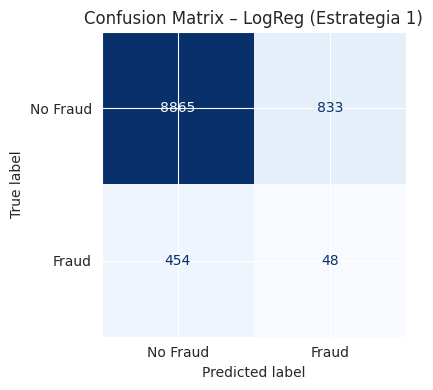

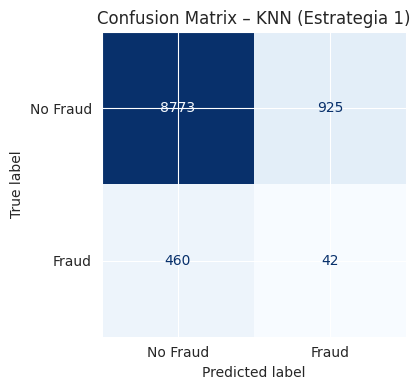

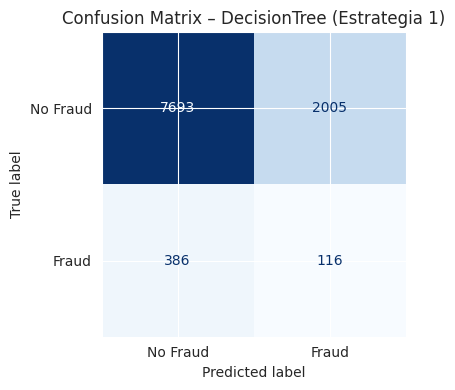

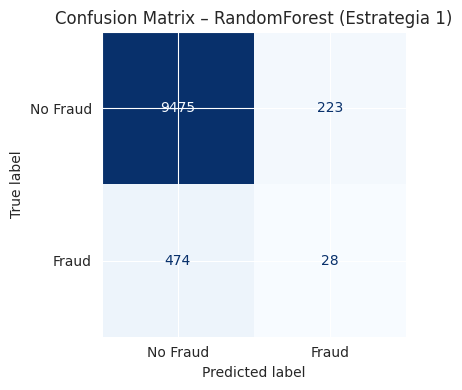

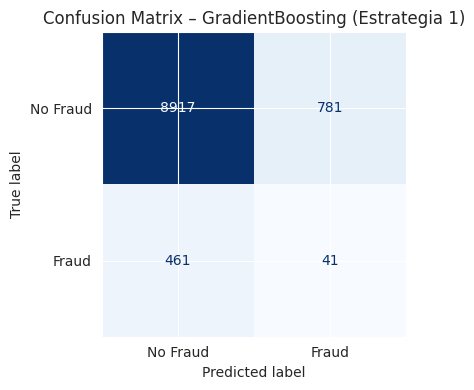

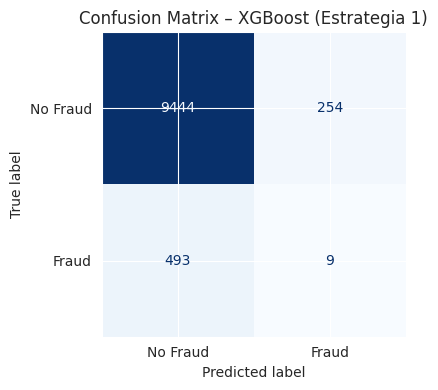

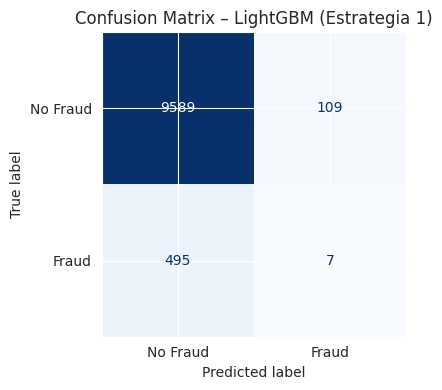

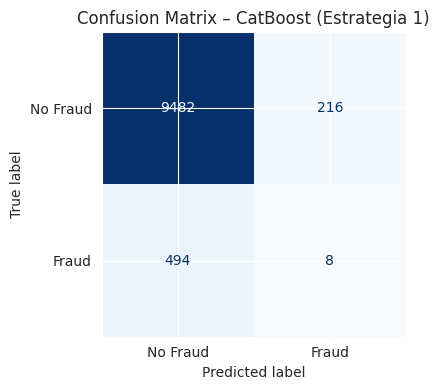

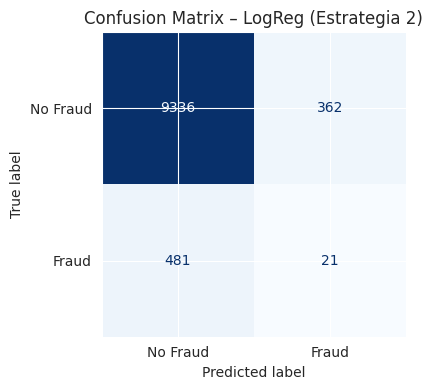

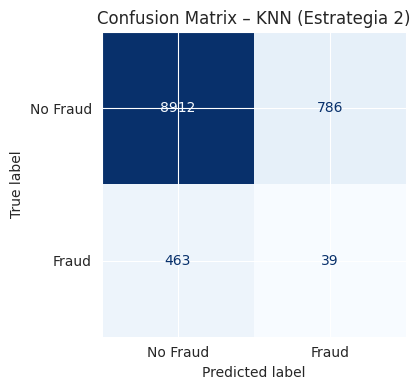

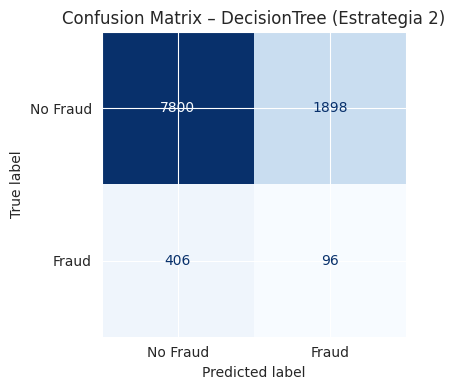

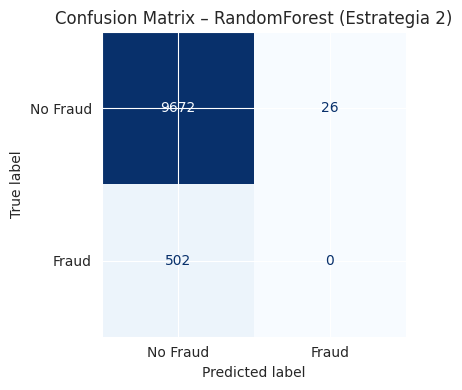

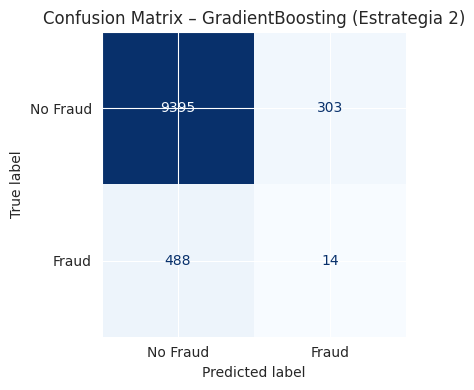

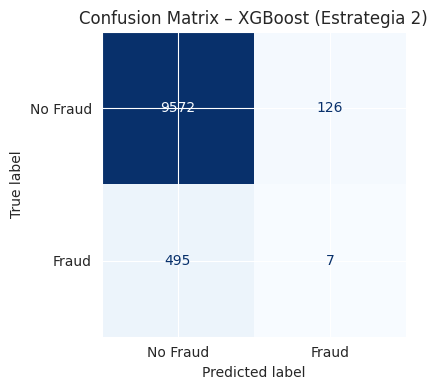

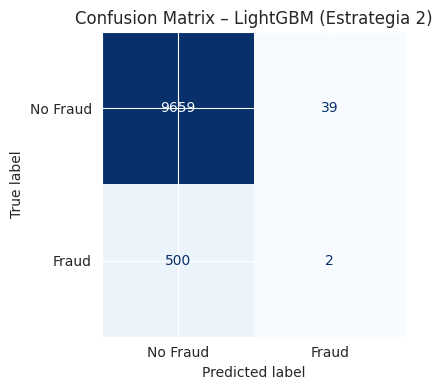

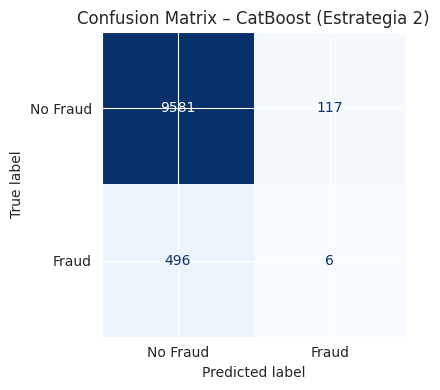

In [76]:
def plot_conf_matrix(model, X_test, Y_test, title, threshold=None):
    """
    Grafica la matriz de confusión para un modelo de clasificación binaria.

    Parámetros:
    - model: modelo entrenado
    - X_test: features de test
    - Y_test: target de test
    - title: título del gráfico
    - threshold: si se especifica, usa predict_proba/score para clasificar
    """

    # Predicción
    if threshold is None:
        y_pred = model.predict(X_test)
    else:
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_test)
        else:
            raise ValueError(f"El modelo {title} no soporta threshold custom.")

        y_pred = (y_score >= threshold).astype(int)

    # Matriz de confusión
    cm = confusion_matrix(Y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Fraud", "Fraud"]
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return cm

best_model_s1_name = results_s1.sort_values("PR_AUC", ascending=False).iloc[0]["Model"]
best_model_s2_name = results_s2.sort_values("PR_AUC", ascending=False).iloc[0]["Model"]

print("Mejor modelo estrategia 1:", best_model_s1_name)
print("Mejor modelo estrategia 2:", best_model_s2_name)


for name, spec in models_s1.items():
    model = spec["model"]
    use_scaled = spec["use_scaled"]

    Xte = data_s1["X_test_scaled"] if use_scaled else data_s1["X_test"]

    plot_conf_matrix(
        model,
        Xte,
        data_s1["y_test"],
        title=f"Confusion Matrix – {name} (Estrategia 1)"
    )

for name, spec in models_s2.items():
    model = spec["model"]
    use_scaled = spec["use_scaled"]

    Xte = data_s2["X_test_scaled"] if use_scaled else data_s2["X_test"]

    plot_conf_matrix(
        model,
        Xte,
        data_s2["y_test"],
        title=f"Confusion Matrix – {name} (Estrategia 2)"
    )


#**6. Feature importance**



,feature,importance
9,Device_Used_Mobile,0.216647
8,Transaction_Type_POS Payment,0.165863
7,Transaction_Type_Online Purchase,0.151137
10,Device_Used_Tablet,0.150011
6,Transaction_Type_Bill Payment,0.114330
5,Transaction_Type_Bank Transfer,0.096659
24,Payment_Method_UPI,0.043300
21,Payment_Method_Debit Card,0.019793
23,Payment_Method_Net Banking,0.018744
25,Payment_Method_Unknown,0.012575


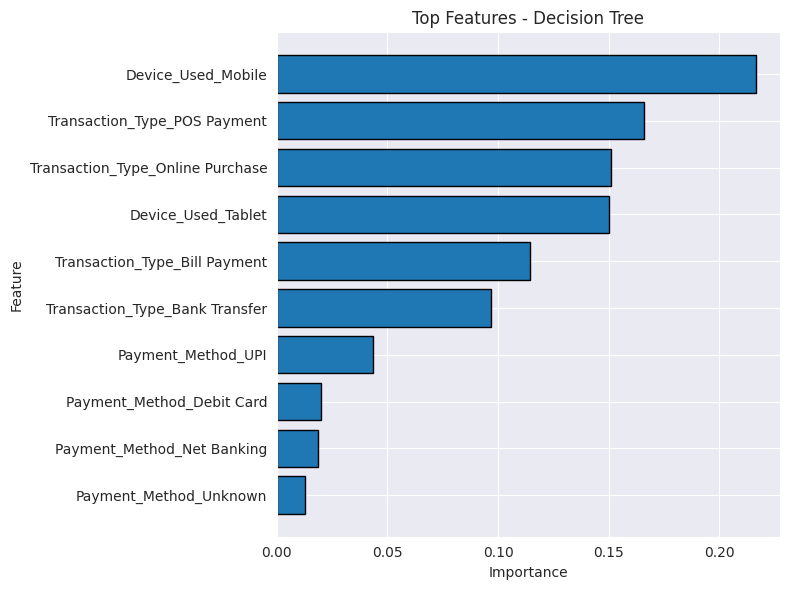

In [78]:
# Nombres de features
feature_names = data_s1["X_test"].columns

# Recuperar el modelo DecisionTree de Estrategia 1
decision_tree_model = models_s1["DecisionTree"]["model"]

#Importancias en el modelo de arbol de decisión
importances = decision_tree_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

display(feat_imp.head(10))


top_n = 10
top_features = feat_imp.head(top_n)

plt.figure(figsize=(8,6))
plt.barh(
    top_features["feature"],
    top_features["importance"],
    edgecolor="black"
)

plt.gca().invert_yaxis()

plt.title("Top Features - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()